# Introduction to convolutional neural networks and computer vision with TensorFlow and Keras
# https://www.tensorflow.org/tutorials/images/cnn

Computer Vision is the practice of writing algorithms which can discover patterns in visual data. It is a subfield of Artificial Intelligence (AI) and Machine Learning (ML) which focuses on enabling computers to see, identify and process images in a way similar to humans. Convolutional Neural Networks (CNNs) are a class of deep learning models that have proven highly effective for image classification tasks.

## get the data

The image we're working wisth are from the Food-101 dataset. It contains 101 different food categories with 101,000 images. You can find the full dataset on [Kaggle](https://www.kaggle.com/dansbecker/food-101). However we've modified it to only use two classes (pizza and steak) using the image data modification notebook: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb

**Note** We start with a smaller dataset so we can experiment quickly. Later on we'll see how to scale this up to larger datasets.

```python
# Download the data (you can also download it manually from Kaggle if you want to see the full dataset)

In [2]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

#Unzip the downloaded file
zip_ref = zipfile.ZipFile("pizza_steak.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2025-10-16 18:19:42--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.151.207, 142.251.30.207, 142.250.117.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.151.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M  23.3MB/s    in 4.5s    

2025-10-16 18:19:46 (23.2 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



## Inspect the data (become one with it)

A very crucial step at the beginning of any machine learning project is to become one with the data. This means understanding the data, its structure, and its characteristics. This step is crucial because it helps in making informed decisions about data preprocessing, model selection, and evaluation metrics.

```python

In [2]:
! ls pizza_steak


test  train


In [3]:
!ls pizza_steak/train/

pizza  steak


In [4]:
!ls pizza_steak/train/pizza

1008104.jpg  1638227.jpg  2235981.jpg  2774899.jpg  3464027.jpg  576236.jpg
1008144.jpg  1646974.jpg  2236914.jpg  2775763.jpg  3464858.jpg  5764.jpg
1008844.jpg  1649108.jpg  2241448.jpg  2778214.jpg  3473991.jpg  579691.jpg
1008941.jpg  1649276.jpg  2247711.jpg  277963.jpg   3475936.jpg  593400.jpg
1011404.jpg  1652943.jpg  2253670.jpg  2785084.jpg  3478964.jpg  59445.jpg
102037.jpg   1654444.jpg  2255361.jpg  2793535.jpg  3479875.jpg  596494.jpg
1026922.jpg  1660415.jpg  2274117.jpg  27963.jpg    3479936.jpg  598381.jpg
1029698.jpg  1663749.jpg  2279642.jpg  2800325.jpg  3484590.jpg  604977.jpg
1033251.jpg  1665654.jpg  2280345.jpg  2811032.jpg  3493457.jpg  608085.jpg
1035854.jpg  166823.jpg   2285269.jpg  282013.jpg   349946.jpg	 618021.jpg
1038357.jpg  1670471.jpg  2285942.jpg  2821034.jpg  350358.jpg	 61822.jpg
1040878.jpg  1671531.jpg  228778.jpg   2821048.jpg  3505182.jpg  618348.jpg
1044524.jpg  1678284.jpg  2291093.jpg  2827938.jpg  3512070.jpg  625687.jpg
1044789.jpg  16810

In [5]:
import os as os
# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak/test'.
There are 0 directories and 250 images in 'pizza_steak/test/pizza'.
There are 0 directories and 250 images in 'pizza_steak/test/steak'.
There are 2 directories and 0 images in 'pizza_steak/train'.
There are 0 directories and 750 images in 'pizza_steak/train/pizza'.
There are 0 directories and 750 images in 'pizza_steak/train/steak'.


In [6]:
# The extra file in our pizza_steak directory is called '.DS_Store' which is a macOS system file that stores custom attributes of a folder such as the position of icons or the choice of a background image. It is not needed for our purposes and can be ignored.

!ls -la pizza_steak

total 16
drwxr-xr-x 4 leohf leohf 4096 Oct 16 18:19 .
drwxr-xr-x 7 leohf leohf 4096 Oct 16 18:19 ..
drwxr-xr-x 4 leohf leohf 4096 Oct 16 18:19 test
drwxr-xr-x 4 leohf leohf 4096 Oct 16 18:19 train


In [7]:
# another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

To visualise our images, first lets get the class names programmatically

In [8]:
# get the class names programmatically
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Create a list of class_names from the subdirectories
print(class_names)

['pizza' 'steak']


In [14]:
# lets visualize our images

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import random

def view_random_image(target_dir, target_class):
    #Set up the target directory
    target_folder = target_dir+target_class
    #Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)

    #read the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");
 # show the shape of the image
    print(f"Image type: {type(img)}")
    print(f"Image shape: {img.shape}")
    print(f"Image min value: {np.min(img)}")
    print(f"Image max value: {np.max(img)}")

    return img

['218711.jpg']
Image type: <class 'numpy.ndarray'>
Image shape: (512, 382, 3)
Image min value: 0
Image max value: 255


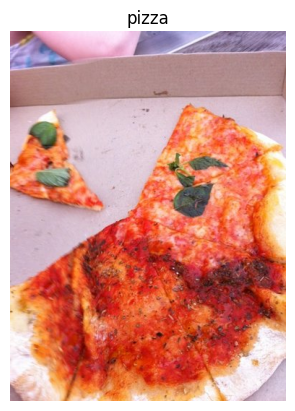

In [44]:
#View a random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train/", target_class="pizza")

In [45]:
img

array([[[181, 119, 144],
        [176, 114, 139],
        [170, 106, 132],
        ...,
        [134, 114, 151],
        [137, 117, 154],
        [149, 129, 166]],

       [[179, 117, 142],
        [175, 113, 138],
        [170, 106, 132],
        ...,
        [142, 122, 159],
        [144, 124, 161],
        [153, 133, 170]],

       [[176, 112, 138],
        [173, 109, 135],
        [170, 104, 131],
        ...,
        [138, 120, 158],
        [142, 124, 162],
        [148, 130, 168]],

       ...,

       [[173, 135, 148],
        [171, 133, 146],
        [167, 129, 140],
        ...,
        [215, 194, 209],
        [217, 196, 211],
        [215, 194, 209]],

       [[176, 136, 147],
        [174, 134, 145],
        [171, 131, 142],
        ...,
        [215, 194, 209],
        [217, 196, 211],
        [215, 194, 209]],

       [[176, 136, 147],
        [175, 135, 146],
        [172, 132, 143],
        ...,
        [217, 196, 211],
        [219, 198, 213],
        [218, 197, 212]]

In [46]:
import tensorflow as tf
tf.constant(img)

2025-10-16 21:35:35.380107: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-16 21:35:42.585538: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<tf.Tensor: shape=(512, 382, 3), dtype=uint8, numpy=
array([[[181, 119, 144],
        [176, 114, 139],
        [170, 106, 132],
        ...,
        [134, 114, 151],
        [137, 117, 154],
        [149, 129, 166]],

       [[179, 117, 142],
        [175, 113, 138],
        [170, 106, 132],
        ...,
        [142, 122, 159],
        [144, 124, 161],
        [153, 133, 170]],

       [[176, 112, 138],
        [173, 109, 135],
        [170, 104, 131],
        ...,
        [138, 120, 158],
        [142, 124, 162],
        [148, 130, 168]],

       ...,

       [[173, 135, 148],
        [171, 133, 146],
        [167, 129, 140],
        ...,
        [215, 194, 209],
        [217, 196, 211],
        [215, 194, 209]],

       [[176, 136, 147],
        [174, 134, 145],
        [171, 131, 142],
        ...,
        [215, 194, 209],
        [217, 196, 211],
        [215, 194, 209]],

       [[176, 136, 147],
        [175, 135, 146],
        [172, 132, 143],
        ...,
        [217, 196, 21